# Regression-Model training and Evaluation

## --> Evaluation using

# Linear Regression

								
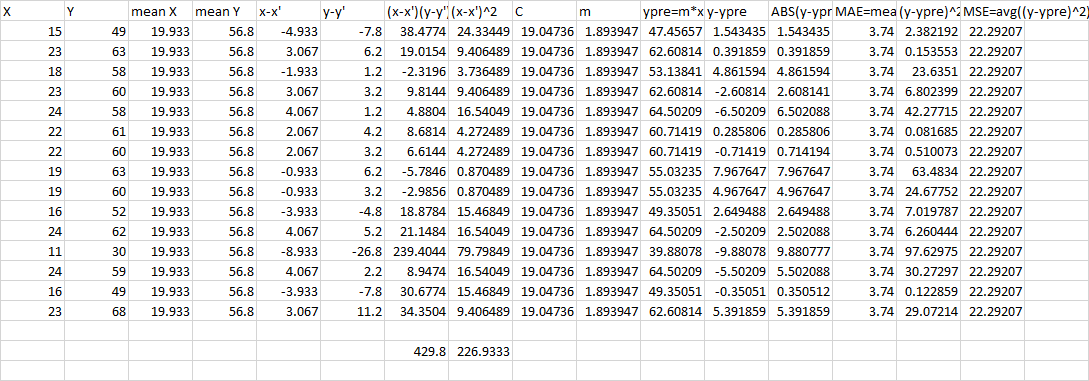

In [2]:
import pandas as pd

data=pd.read_csv("test1.csv")
df=pd.DataFrame(data)
df

,X,Y
0,15,49
1,23,63
2,18,58
3,23,60
4,24,58
5,22,61
6,22,60
7,19,63
8,19,60
9,16,52


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X       15 non-null     int64
 1   Y       15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes


In [4]:
df.isna().sum()

X    0
Y    0
dtype: int64

In [5]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]
print(type(x)) # DataFrame
print(type(y)) # Series
print(x)
print("-"*50)
print(y)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
     X
0   15
1   23
2   18
3   23
4   24
5   22
6   22
7   19
8   19
9   16
10  24
11  11
12  24
13  16
14  23
--------------------------------------------------
0     49
1     63
2     58
3     60
4     58
5     61
6     60
7     63
8     60
9     52
10    62
11    30
12    59
13    49
14    68
Name: Y, dtype: int64


In [6]:
print(x.shape)
print(y.shape)

(15, 1)
(15,)


In [7]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(13, 1)
(2, 1)
(13,)
(2,)


In [8]:
from sklearn.linear_model import LinearRegression 

lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[62.41322902 54.56827881]


In [9]:
print(x_test)

    X
3  23
7  19


In [10]:
print(y_test)

3    60
7    63
Name: Y, dtype: int64


In [11]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
diff

,Actual,Predicted
3,60,62.413229
7,63,54.568279


In [12]:
print("Coofficient :",lr.coef_)
print("Intercept :",lr.intercept_)

Coofficient : [1.96123755]
Intercept : 17.30476529160739


In [13]:
from sklearn.linear_model import LinearRegression 

lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
print(y_pred)

[47.45652174 62.60810811 53.13836663 62.60810811 64.5020564  60.71415981
 60.71415981 55.03231492 55.03231492 49.35047004 64.5020564  39.88072855
 64.5020564  49.35047004 62.60810811]


In [14]:
print("Coofficient :",lr.coef_)
print("Intercept :",lr.intercept_)  # because we did not give value to train 

Coofficient : [1.8939483]
Intercept : 19.047297297297284


In [15]:
from sklearn import metrics

print("MAE : ",metrics.mean_absolute_error(y, y_pred))
print("MSE : ",metrics.mean_squared_error(y, y_pred))
print("R2 : ",metrics.r2_score(y, y_pred))



MAE :  3.7412847630238946
MSE :  22.292068155111636
R2 :  0.7088287858527738


In [16]:
# Actual   Pred
#  80       78
#  70       72
#  90       85

# mean y = (80+70+90)/3
#        = 80

# R^2 = 1 - (ss_res/ss_total)   (ss=sum of squre)
# ss_total = (80-80)^2+(70-80)^2+(90-80)^2=200
# ss_res = (80-78)^2 + (70-72)^2 + (90-85)^2 = 33
# R^2 = 1 - (33/200) = 0.835

In [17]:
from sklearn.linear_model import LinearRegression 

lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict([[18]])
print(y_pred)

[53.13836663]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# --------------------

In [2]:
import pandas as pd
data={
    "Hours Studied":[1,2,3,4,5,6,7],
    "Exam Score":[50,55,65,70,75,80,85]
}

# x=np.array([[1],[2],[3],[4],[5],[6],[7]])
# y=np.array([50,55,65,70,75,80,85])

df=pd.DataFrame(data)
df

,Hours Studied,Exam Score
0,1,50
1,2,55
2,3,65
3,4,70
4,5,75
5,6,80
6,7,85


In [3]:
x=df[["Hours Studied"]]
# x=df.iloc[:,0:1]
x

,Hours Studied
0,1
1,2
2,3
3,4
4,5
5,6
6,7


In [11]:
y=df["Exam Score"]
# y=df.iloc[:,-1]
y

0    50
1    55
2    65
3    70
4    75
5    80
6    85
Name: Exam Score, dtype: int64

In [8]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
print(y_pred)

[50.89285714 56.78571429 62.67857143 68.57142857 74.46428571 80.35714286
 86.25      ]


In [9]:
diff=pd.DataFrame({"Actual":y,"Predicted":y_pred})
diff

,Actual,Predicted
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286
5,80,80.357143
6,85,86.250000


In [12]:
from sklearn import metrics

print("MAE : ",metrics.mean_absolute_error(y, y_pred))
print("MSE : ",metrics.mean_squared_error(y, y_pred))
print("R2 : ",metrics.r2_score(y, y_pred))

MAE :  1.2244897959183672
MSE :  1.9132653061224514
R2 :  0.9864130434782609


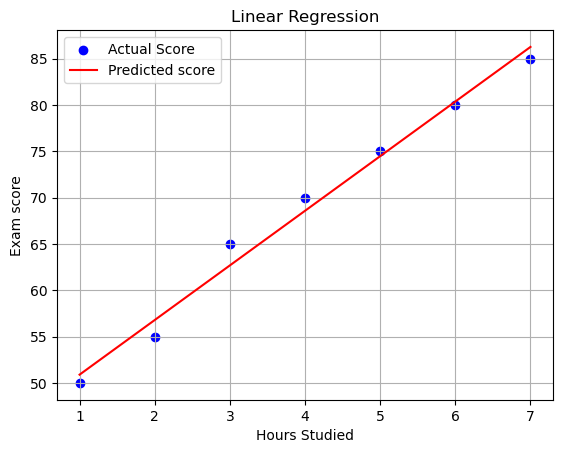

In [15]:
import matplotlib.pyplot as plt

plt.scatter(x,y,color="blue",label="Actual Score")
plt.plot(x,y_pred,color="red",label="Predicted score")

plt.xlabel("Hours Studied")
plt.ylabel("Exam score")

plt.title("Linear Regression")

plt.legend()
plt.grid(True)
plt.show()

# --------------------------

In [3]:
import pandas as pd

df=pd.read_csv("book1.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
df.isna().sum()

cgpa       0
package    0
dtype: int64

In [5]:
x=df[["cgpa"]]
y=df["package"]

In [6]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(180, 1)
(20, 1)
(180,)
(20,)


In [7]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[2.95599947 4.35419203 3.19471527 1.93861546 3.50163559 3.35954285
 2.79117189 2.96736689 3.08672479 3.93928123 3.57552382 2.96736689
 2.77980448 2.67181399 3.67214688 3.22881753 3.97338349 2.92758092
 2.22848465 3.31975689]


In [8]:
x_test

,cgpa
58,6.92
40,9.38
34,7.34
102,5.13
184,7.88
198,7.63
95,6.63
4,6.94
29,7.15
168,8.65


In [9]:
y_test

58     3.09
40     4.02
34     3.42
102    1.37
184    3.14
198    3.96
95     2.79
4      3.57
29     3.49
168    3.52
171    3.76
18     2.98
11     2.60
89     2.72
110    3.76
118    2.88
159    4.08
35     2.87
136    2.10
59     3.31
Name: package, dtype: float64

In [12]:
from sklearn import metrics

print("MAE : ",metrics.mean_absolute_error(y_test, y_pred))
print("MSE : ",metrics.mean_squared_error(y_test, y_pred))
print("R2 : ",metrics.r2_score(y_test, y_pred))

MAE :  0.2407378157739672
MSE :  0.09630812755183496
R2 :  0.7763411228752372


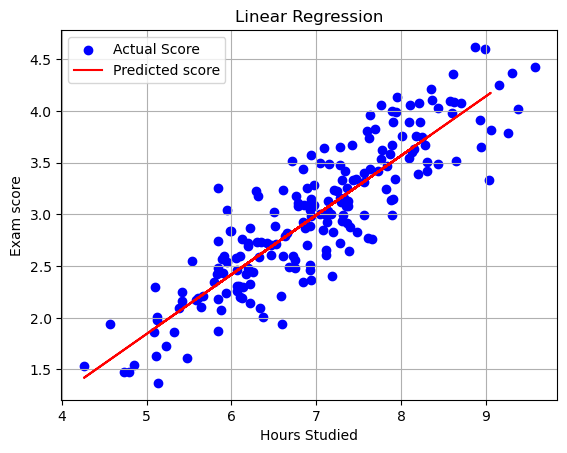

In [29]:
import matplotlib.pyplot as plt

plt.scatter(x,y,color="blue",label="Actual Score")
plt.plot(x_test,y_pred,color="red",label="Predicted score")

plt.xlabel("Hours Studied")
plt.ylabel("Exam score")

plt.title("Linear Regression")

plt.legend()
plt.grid(True)
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

min1=1000
st=0
abso=0
for i in range(1,43):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)
    
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    abso=metrics.mean_absolute_error(y_test, y_pred)

    if(abso<min1):
        min1=abso
        st=i
        
print(st)
print(min1)

19
0.18405380979816172


<Axes: xlabel='cgpa', ylabel='package'>

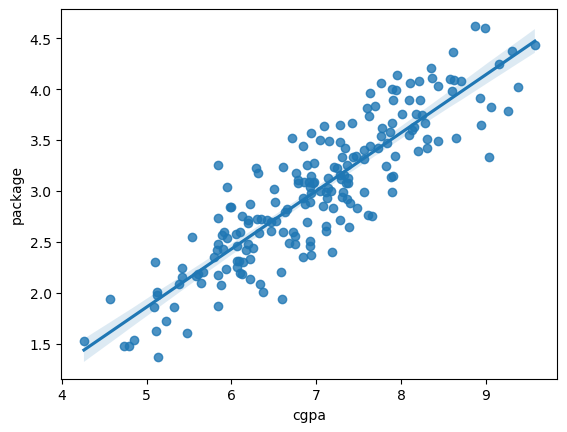

In [28]:
import seaborn as sns

sns.regplot(data=df,x="cgpa",y="package")

In [30]:
y_pred=lr.predict([[6.5]])
print(y_pred)

[2.70566014]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# ---------------------------
# Predict the selling price (Multiple Linear Regration)

In [3]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [4]:
df.drop(columns= "Car_Name",inplace=True)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
df["Age"]=2026-df["Year"]
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [6]:
df.drop("Year",axis=1,inplace=True)
df

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [7]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Age'],
      dtype='object')

In [8]:
df=pd.get_dummies(data=df,drop_first=True)
df

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,10,True,False,False,True
297,4.00,5.90,60000,0,11,False,True,False,True
298,3.35,11.00,87934,0,17,False,True,False,True
299,11.50,12.50,9000,0,9,True,False,False,True


In [9]:
y=df["Selling_Price"]
#x=df.iloc[:,1:]
x=df.drop("Selling_Price",axis=1)

In [10]:
x

,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,12,False,True,False,True
1,9.54,43000,0,13,True,False,False,True
2,9.85,6900,0,9,False,True,False,True
3,4.15,5200,0,15,False,True,False,True
4,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...
296,11.60,33988,0,10,True,False,False,True
297,5.90,60000,0,11,False,True,False,True
298,11.00,87934,0,17,False,True,False,True
299,12.50,9000,0,9,True,False,False,True


In [11]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 8)
(61, 8)
(240,)
(61,)


In [20]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[ 7.86273200e+00  2.96828691e+00 -5.90305107e-01  4.21335952e+00
  4.83175534e-01  5.82053813e+00  1.95679784e+00  2.55809661e+00
  7.70870833e+00  9.78692192e-01  8.13484343e+00  3.51207180e+00
  4.90669281e+00  4.63905587e+00 -2.15886643e+00  3.13874624e+00
  7.98256903e+00  6.75937638e+00  6.90426580e+00  8.01440587e+00
  4.31168610e+00  4.00336757e+00  1.13040883e+01  8.07939189e+00
  9.54399823e+00  3.52133877e+00  3.80609808e+00  1.06074722e+00
 -6.01732475e-01 -6.19712043e-01  1.32818516e-03 -1.28500691e+00
  4.28533553e+00  2.06769487e+01  1.87563232e+01  4.27292100e+00
  3.48602852e+00  1.66739677e+00 -4.38707073e-02  5.78536030e+00
  8.03940428e+00  9.88367483e+00  4.09684249e-01  6.07997517e+00
  5.88038915e+00  4.32745252e+00  7.37534505e+00  5.86171335e+00
  8.21129880e+00  1.65455816e+00  3.83033706e+00  1.75047060e+00
  2.51406796e+00  4.20404709e+00  1.48991546e+00 -3.44185843e+00
  2.04806215e+01  6.62503544e-01  5.40027412e+00  5.65856241e+00
  6.47876234e-01]


In [21]:
from sklearn import metrics

print("MAE : ",metrics.mean_absolute_error(y_test, y_pred))
print("MSE : ",metrics.mean_squared_error(y_test, y_pred))
print("R2 : ",metrics.r2_score(y_test, y_pred))

MAE :  1.0998575552990955
MSE :  2.9823848618597513
R2 :  0.8625260513315252


In [22]:
print("Coofficient :",lr.coef_)
print("Intercept :",lr.intercept_)

Coofficient : [ 4.37233976e-01 -5.30613944e-06  3.45912849e-01 -4.13270098e-01
  2.23050770e+00  4.58549217e-01 -1.20927814e+00 -1.87014327e+00]
Intercept : 7.900300130264206


In [27]:
y_pred=lr.predict([[5.5,25000,0,5,0,1,1,1]])
print(y_pred)

[5.48521083]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd

df=pd.read_csv("Advertising.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [2]:
df.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [8]:
df.drop(columns="",axis=1,inplace=True)
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
y=df["Sales"]
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [5]:
x=df.drop("Sales",axis=1)
x

,Unnamed: 0,TV,Radio,Newspaper
0,1,230.1,37.8,69.2
1,2,44.5,39.3,45.1
2,3,17.2,45.9,69.3
3,4,151.5,41.3,58.5
4,5,180.8,10.8,58.4
...,...,...,...,...
195,196,38.2,3.7,13.8
196,197,94.2,4.9,8.1
197,198,177.0,9.3,6.4
198,199,283.6,42.0,66.2


In [9]:
import pandas as pd
import pandas as pd
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import metrics  

lr = LinearRegression()
lr.fit(x, y)

ypre = lr.predict(x)

diff = pd.DataFrame({
    'Actual': y,
    'Predicted': ypre,
    'Difference': y - ypre
})

print(diff)
print("MAE : ", metrics.mean_absolute_error(y, ypre))
print("MSE : ", metrics.mean_squared_error(y, ypre))

     Actual  Predicted  Difference
0      22.1  20.572515    1.527485
1      10.4  12.388463   -1.988463
2       9.3  12.351441   -3.051441
3      18.5  17.645433    0.854567
4      12.9  13.240525   -0.340525
..      ...        ...         ...
195     7.6   5.320063    2.279937
196     9.7   8.116082    1.583918
197    12.8  12.736748    0.063252
198    25.5  23.701660    1.798340
199    13.4  15.123113   -1.723113

[200 rows x 3 columns]
MAE :  1.2527245713833053
MSE :  2.7830374983314266


In [15]:
import pandas as pd

df=pd.read_csv("FuelConsumptionCo2.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [16]:
df.drop(columns=["MAKE","MODEL","VEHICLECLASS","TRANSMISSION"],axis=1,inplace=True)
df

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,2.0,4,Z,9.9,6.7,8.5,33,196
1,2014,2.4,4,Z,11.2,7.7,9.6,29,221
2,2014,1.5,4,Z,6.0,5.8,5.9,48,136
3,2014,3.5,6,Z,12.7,9.1,11.1,25,255
4,2014,3.5,6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...
1062,2014,3.0,6,X,13.4,9.8,11.8,24,271
1063,2014,3.2,6,X,13.2,9.5,11.5,25,264
1064,2014,3.0,6,X,13.4,9.8,11.8,24,271
1065,2014,3.2,6,X,12.9,9.3,11.3,25,260


In [17]:
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [18]:
df=pd.get_dummies(data=df,drop_first=True)
df

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,FUELTYPE_E,FUELTYPE_X,FUELTYPE_Z
0,2014,2.0,4,9.9,6.7,8.5,33,196,False,False,True
1,2014,2.4,4,11.2,7.7,9.6,29,221,False,False,True
2,2014,1.5,4,6.0,5.8,5.9,48,136,False,False,True
3,2014,3.5,6,12.7,9.1,11.1,25,255,False,False,True
4,2014,3.5,6,12.1,8.7,10.6,27,244,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,3.0,6,13.4,9.8,11.8,24,271,False,True,False
1063,2014,3.2,6,13.2,9.5,11.5,25,264,False,True,False
1064,2014,3.0,6,13.4,9.8,11.8,24,271,False,True,False
1065,2014,3.2,6,12.9,9.3,11.3,25,260,False,True,False


# Poly Linear Regression

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import metrics


df = pd.read_csv("polylinearregression.csv")


x = df.iloc[:, :-1] 
y = df.iloc[:, -1]

lr = LinearRegression()
lr.fit(x, y)

ypre = lr.predict(x)

mae = metrics.mean_absolute_error(y, ypre)
mse = metrics.mean_squared_error(y, ypre)
r2 = metrics.r2_score(y, ypre)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE) : {mse}")
print(f"R-squared Score (R2)     : {r2}")


Mean Absolute Error (MAE): 0.047653333333333346
Mean Squared Error (MSE) : 0.0028702675555555574
R-squared Score (R2)     : 0.690349972603981


C:\Users\LJENG\AppData\Local\Temp\ipykernel_13452\1903322715.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


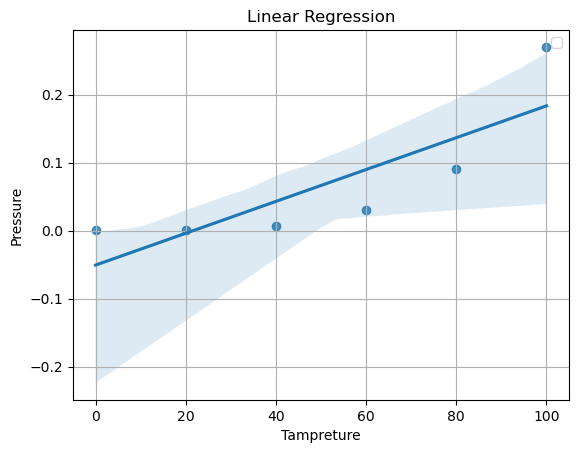

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.regplot(data=df,x="Temperature",y="Pressure")

plt.xlabel("Tampreture")
plt.ylabel("Pressure")

plt.title("Linear Regression")

plt.legend()
plt.grid(True)
plt.show()

In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)

print(x_poly)

[[1.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00 0.00e+00 1.00e+00 0.00e+00
  0.00e+00 0.00e+00]
 [1.00e+00 2.00e+00 2.00e+01 4.00e+00 4.00e+01 4.00e+02 8.00e+00 8.00e+01
  8.00e+02 8.00e+03]
 [1.00e+00 3.00e+00 4.00e+01 9.00e+00 1.20e+02 1.60e+03 2.70e+01 3.60e+02
  4.80e+03 6.40e+04]
 [1.00e+00 4.00e+00 6.00e+01 1.60e+01 2.40e+02 3.60e+03 6.40e+01 9.60e+02
  1.44e+04 2.16e+05]
 [1.00e+00 5.00e+00 8.00e+01 2.50e+01 4.00e+02 6.40e+03 1.25e+02 2.00e+03
  3.20e+04 5.12e+05]
 [1.00e+00 6.00e+00 1.00e+02 3.60e+01 6.00e+02 1.00e+04 2.16e+02 3.60e+03
  6.00e+04 1.00e+06]]


In [4]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)

print(x_poly)

[[1.0e+00 1.0e+00 0.0e+00 1.0e+00 0.0e+00 0.0e+00]
 [1.0e+00 2.0e+00 2.0e+01 4.0e+00 4.0e+01 4.0e+02]
 [1.0e+00 3.0e+00 4.0e+01 9.0e+00 1.2e+02 1.6e+03]
 [1.0e+00 4.0e+00 6.0e+01 1.6e+01 2.4e+02 3.6e+03]
 [1.0e+00 5.0e+00 8.0e+01 2.5e+01 4.0e+02 6.4e+03]
 [1.0e+00 6.0e+00 1.0e+02 3.6e+01 6.0e+02 1.0e+04]]


In [5]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([ 0.01555, -0.01731, -0.01032,  0.03652,  0.12321,  0.24975])

Polynomial MAE: 0.018359999999999998
Polynomial MSE: 0.0004000103333333331
Polynomial R2 : 0.9568461098911795


C:\ProgramData\Anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
C:\ProgramData\Anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
C:\ProgramData\Anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
C:\ProgramData\Anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
C:\ProgramData\Anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
C:\ProgramData\Anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x

<Axes: xlabel='Temperature', ylabel='Pressure'>

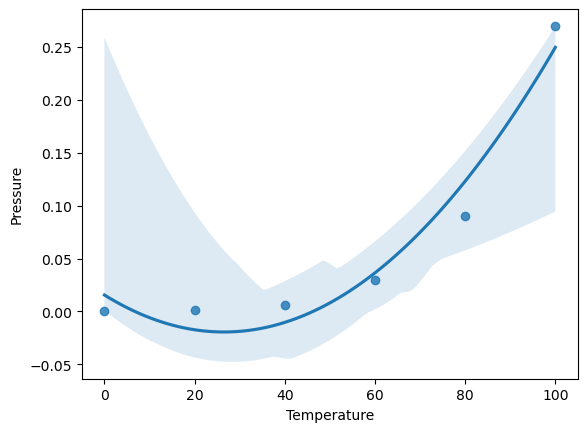

In [6]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures


df = pd.read_csv("polylinearregression.csv")
x = df.iloc[:, :-1] 
y = df.iloc[:, -1]


poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)


poly_lr = LinearRegression()
poly_lr.fit(x_poly, y)

y_poly_pre = poly_lr.predict(x_poly)


print(f"Polynomial MAE: {metrics.mean_absolute_error(y, y_poly_pre)}")
print(f"Polynomial MSE: {metrics.mean_squared_error(y, y_poly_pre)}")
print(f"Polynomial R2 : {metrics.r2_score(y, y_poly_pre)}")

# 6. Visualization
sns.regplot(data=df, x="Temperature", y="Pressure", order=2)


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures


df = pd.read_csv("polylinearregression.csv")
x = df.iloc[:, :-1] 
y = df.iloc[:, -1]


poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)


poly_lr = LinearRegression()
poly_lr.fit(x_poly, y)

y_poly_pre = poly_lr.predict(x_poly)


print(f"Polynomial MAE: {metrics.mean_absolute_error(y, y_poly_pre)}")
print(f"Polynomial MSE: {metrics.mean_squared_error(y, y_poly_pre)}")
print(f"Polynomial R2 : {metrics.r2_score(y, y_poly_pre)}")

# 6. Visualization
sns.regplot(data=df, x="Temperature", y="Pressure", order=2)


# ---------------------------------------

In [8]:
import pandas as pd

df=pd.read_csv("car_data.csv")
df

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [9]:
x = df.iloc[:, :-1] 
y = df.iloc[:, -1]

In [10]:
x

,Horsepower,Weight
0,130,3504
1,165,3693
2,150,3436
3,140,3433
4,198,4341
5,220,4354
6,95,2372
7,88,2130
8,98,2228


In [11]:
y

0    18
1    15
2    18
3    16
4    14
5    12
6    25
7    27
8    24
Name: MPG, dtype: int64

In [12]:
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

print(x_poly)  # x1^2 ,x2^2 ,x1 ,x2 ,x1x2

[[1.0000000e+00 1.3000000e+02 3.5040000e+03 1.6900000e+04 4.5552000e+05
  1.2278016e+07]
 [1.0000000e+00 1.6500000e+02 3.6930000e+03 2.7225000e+04 6.0934500e+05
  1.3638249e+07]
 [1.0000000e+00 1.5000000e+02 3.4360000e+03 2.2500000e+04 5.1540000e+05
  1.1806096e+07]
 [1.0000000e+00 1.4000000e+02 3.4330000e+03 1.9600000e+04 4.8062000e+05
  1.1785489e+07]
 [1.0000000e+00 1.9800000e+02 4.3410000e+03 3.9204000e+04 8.5951800e+05
  1.8844281e+07]
 [1.0000000e+00 2.2000000e+02 4.3540000e+03 4.8400000e+04 9.5788000e+05
  1.8957316e+07]
 [1.0000000e+00 9.5000000e+01 2.3720000e+03 9.0250000e+03 2.2534000e+05
  5.6263840e+06]
 [1.0000000e+00 8.8000000e+01 2.1300000e+03 7.7440000e+03 1.8744000e+05
  4.5369000e+06]
 [1.0000000e+00 9.8000000e+01 2.2280000e+03 9.6040000e+03 2.1834400e+05
  4.9639840e+06]]


In [13]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7, 6)
(2, 6)
(7,)
(2,)


lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

In [24]:
x=[1,2,3,4,5]
y=[1,4,9,16,25]

x=pd.DataFrame(x)
y=pd.Series(y)
x

,0
0,1
1,2
2,3
3,4
4,5


In [25]:
y

0     1
1     4
2     9
3    16
4    25
dtype: int64

In [17]:
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

print(x_poly)  # x1^2 ,x2^2 ,x1 ,x2 ,x1x2

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]


In [28]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([ 1.,  4.,  9., 16., 25.])

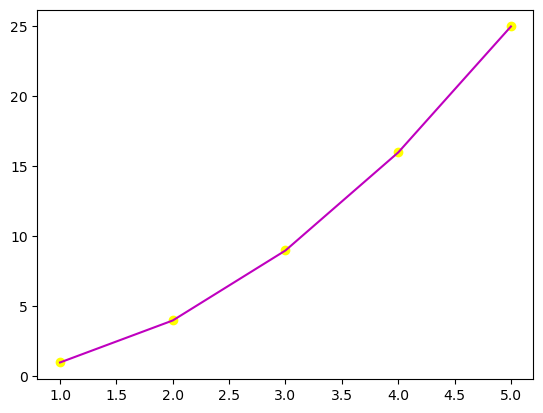

In [29]:

import matplotlib.pyplot as plt
plt.scatter(x,y,color="yellow")
plt.plot(x,y_pred,color="m")
plt.show()